In [3]:
import os
import pandas as pd

current = os.getcwd()
while not os.path.exists(os.path.join(current, "data")):
    current = os.path.dirname(current)


data_path = os.path.join(current, "data", "processed", "train_processed.csv")
df = pd.read_csv(data_path)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_DPD_RATE,POS_CNT_INSTALMENT_MEAN,CC_COUNT,CC_CC_UTIL_RATE_MEAN,CC_CC_UTIL_RATE_MAX,CC_CC_DRAWING_RATE_MEAN,CC_AMT_BALANCE_MEAN,CC_DPD_MEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,24.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,10.107143,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,3.750000,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,12.000000,6.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,15.333333,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Sanity Check

In [3]:
df.shape

(307511, 210)

In [4]:
#check for duplicate sk_id_curr
duplicates = df["SK_ID_CURR"].value_counts()
duplicates = duplicates[duplicates > 1]
print(duplicates)


Series([], Name: count, dtype: int64)


In [5]:
#check for class imbalance
df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [6]:
missing = df.isnull().mean().sort_values(ascending=False)
print(missing.head(20))

CC_CC_DRAWING_RATE_MEAN     0.720218
CC_CC_UTIL_RATE_MAX         0.720218
CC_CC_UTIL_RATE_MEAN        0.720218
CC_COUNT                    0.717392
CC_DPD_MEAN                 0.717392
CC_AMT_BALANCE_MEAN         0.717392
BUREAU_STATUS_WORST_MAX     0.700073
BUREAU_STATUS_MEAN_MEAN     0.700073
BUREAU_STATUS_WORST_MEAN    0.700073
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_MODE              0.678486
dtype: float64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = []

for col in df.columns:
    if col == "TARGET":
        continue

    # Missing mask
    missing_flag = df[col].isna()
    missing_fraction = missing_flag.mean()
    if missing_fraction < 0.30:
        continue

    # Default rate when missing
    missing_rate = df.loc[missing_flag, "TARGET"].mean()

    # Default rate when NOT missing
    not_missing_rate = df.loc[~missing_flag, "TARGET"].mean()

    # Difference
    diff = abs(missing_rate - not_missing_rate)

    results.append({
        "column": col,
        "missing_rate": missing_rate,
        "not_missing_rate": not_missing_rate,
        "difference": diff,
        "missing_fraction": missing_fraction
    })



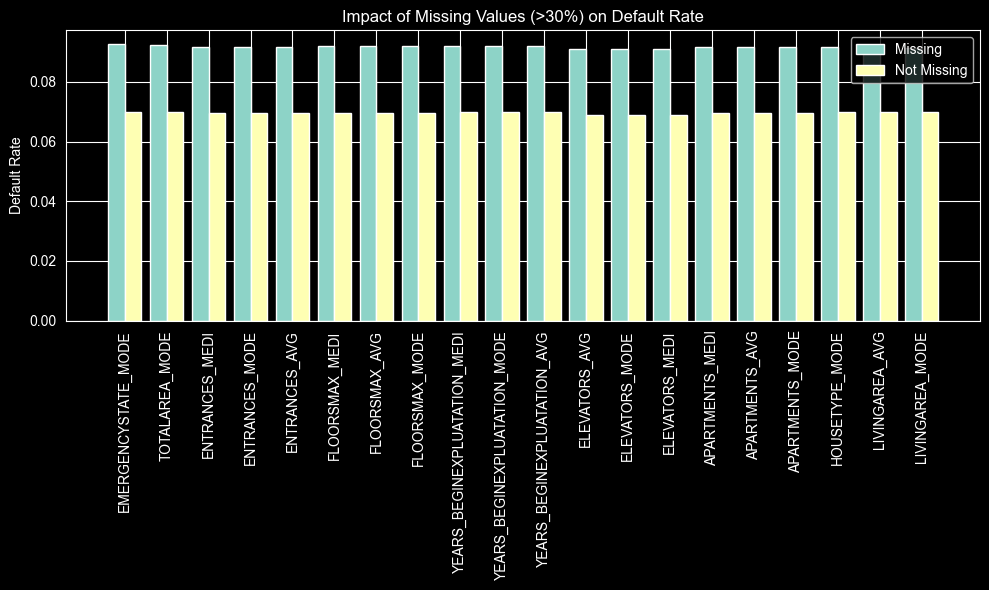

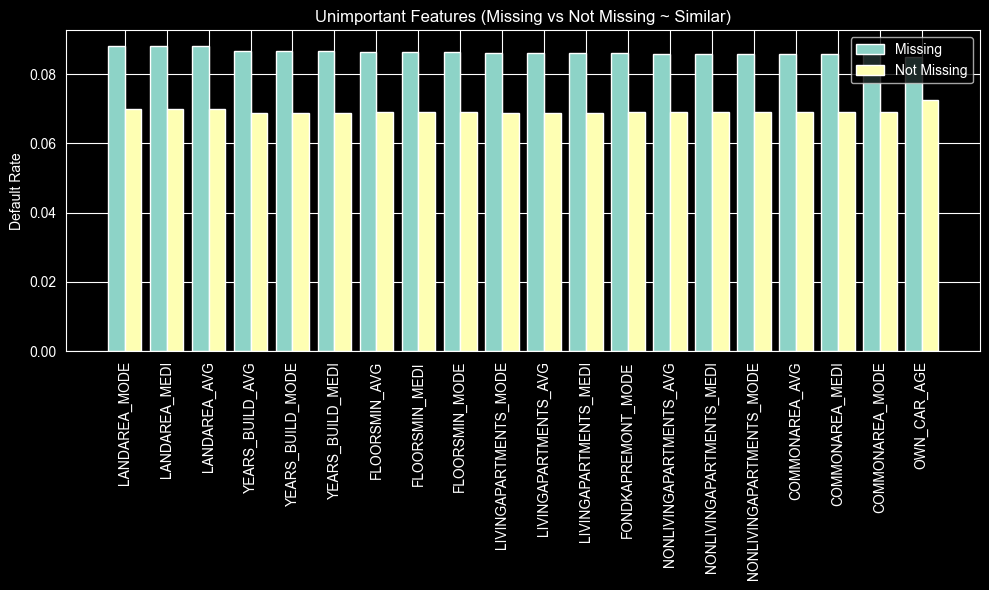

In [5]:
results_df = pd.DataFrame(results)

# Sort by impact
results_df = results_df.sort_values(by="difference", ascending=False)
top_n = 20
top_df = results_df.head(top_n)

plt.figure(figsize=(10, 6))
x = np.arange(len(top_df))
plt.bar(x - 0.2, top_df["missing_rate"], width=0.4, label="Missing")
plt.bar(x + 0.2, top_df["not_missing_rate"], width=0.4, label="Not Missing")
plt.xticks(x, top_df["column"], rotation=90)
plt.ylabel("Default Rate")
plt.title("Impact of Missing Values (>30%) on Default Rate")
plt.legend()

plt.tight_layout()
plt.show()


# Plot UnImportant Columns

threshold = 0.02

# Columns where missingness has LOW impact
unimportant_df = results_df[results_df["difference"] <= threshold]
unimportant_cols = unimportant_df["column"].tolist()
unimportant_df = unimportant_df.sort_values(by="difference", ascending=False)


top_n = 20
plot_df = unimportant_df.head(top_n)
plt.figure(figsize=(10, 6))
x = np.arange(len(plot_df))
plt.bar(x - 0.2, plot_df["missing_rate"], width=0.4, label="Missing")
plt.bar(x + 0.2, plot_df["not_missing_rate"], width=0.4, label="Not Missing")
plt.xticks(x, plot_df["column"], rotation=90)
plt.ylabel("Default Rate")
plt.title("Unimportant Features (Missing vs Not Missing ~ Similar)")
plt.legend()
plt.tight_layout()
plt.show()



### handling missing data

In [6]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns
print("number of categorical columns:", len(cat_cols))
print("number of numerical columns:", len(num_cols))
# Numerical
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Categorical
for col in cat_cols:
    mode_value = df[col].mode(dropna=True)
    if not mode_value.empty:
        df[col] = df[col].fillna(mode_value[0])



C:\Users\abeku\AppData\Local\Temp\ipykernel_14904\108912413.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


number of categorical columns: 24
number of numerical columns: 186


### Training Baseline Logistic Regression

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[39974 16564]
 [ 1491  3474]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.70      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.71      0.77     61503


ROC-AUC: 0.7708161310431643


### Tuning Threshold

In [10]:

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.0, 1.01, 0.01)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

results_df = pd.DataFrame(results)


In [13]:
recall_threshold = 0.6

filtered_df = results_df[results_df["recall"] >= recall_threshold]
if filtered_df.empty:
    print("No threshold satisfies the recall constraint. Lower the constraint.")
else:
    best_row = filtered_df.loc[filtered_df["precision"].idxmax()]

    print("Best Threshold under Recall Constraint:")
    print(best_row)
best_threshold = best_row["threshold"]

y_pred_final = (y_prob >= best_threshold).astype(int)
from sklearn.metrics import classification_report, confusion_matrix

print("Final Threshold:", best_threshold)
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))



Best Threshold under Recall Constraint:
threshold    0.570000
precision    0.201987
recall       0.610272
f1           0.303516
Name: 57, dtype: float64
Final Threshold: 0.5700000000000001
[[44567 11971]
 [ 1935  3030]]
              precision    recall  f1-score   support

           0       0.96      0.79      0.87     56538
           1       0.20      0.61      0.30      4965

    accuracy                           0.77     61503
   macro avg       0.58      0.70      0.58     61503
weighted avg       0.90      0.77      0.82     61503



## SMOTE + Undersampling

In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [15]:
# SMOTE oversamples minority to 20% of majority count;
# RandomUnderSampler then brings majority down to 2x minority count
smote = SMOTE(sampling_strategy=0.2, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

resample_pipeline = ImbPipeline(steps=[
    ('smote', smote),
    ('under', under)
])

X_train_res, y_train_res = resample_pipeline.fit_resample(X_train_scaled, y_train)

print('Original class distribution:')
print(y_train.value_counts())
print('\nResampled class distribution:')
unique, counts = np.unique(y_train_res, return_counts=True)
print(dict(zip(unique, counts)))


Original class distribution:
TARGET
0    226148
1     19860
Name: count, dtype: int64

Resampled class distribution:
{np.int64(0): np.int64(90458), np.int64(1): np.int64(45229)}


In [16]:
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_res, y_train_res)

y_pred_smote = model_smote.predict(X_test_scaled)
y_prob_smote = model_smote.predict_proba(X_test_scaled)[:, 1]

print('=== SMOTE + Undersample Model (default threshold=0.5) ===')
print('\nClassification Report:\n', classification_report(y_test, y_pred_smote))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_smote))

=== SMOTE + Undersample Model (default threshold=0.5) ===

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91     56538
           1       0.24      0.46      0.31      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.67      0.61     61503
weighted avg       0.89      0.84      0.86     61503

ROC-AUC: 0.7651129094720385
